<a href="https://colab.research.google.com/github/ayualfia/PBA-Amazon-SentimentAnalysis/blob/main/week4_amazon_shopping_reviews_EDA_%26_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

df = pd.read_csv('df_amazon_reviews2.csv')

print("INFO DATA:")
df.info()

INFO DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282912 entries, 0 to 282911
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 282912 non-null  object 
 1   score                   282912 non-null  int64  
 2   thumbsUpCount           282912 non-null  int64  
 3   reviewCreatedVersion    282912 non-null  object 
 4   at                      282912 non-null  object 
 5   appVersion              282912 non-null  object 
 6   id                      282912 non-null  int64  
 7   sentiment_polarity      282912 non-null  float64
 8   sentiment_subjectivity  282912 non-null  float64
 9   sentiment_rating        282912 non-null  object 
 10  final_cleaned           282905 non-null  object 
 11  token                   282912 non-null  object 
 12  token_after_sr          282912 non-null  object 
 13  lemmatized_tokens       282912 non-null  object 
 14  cleaned_t

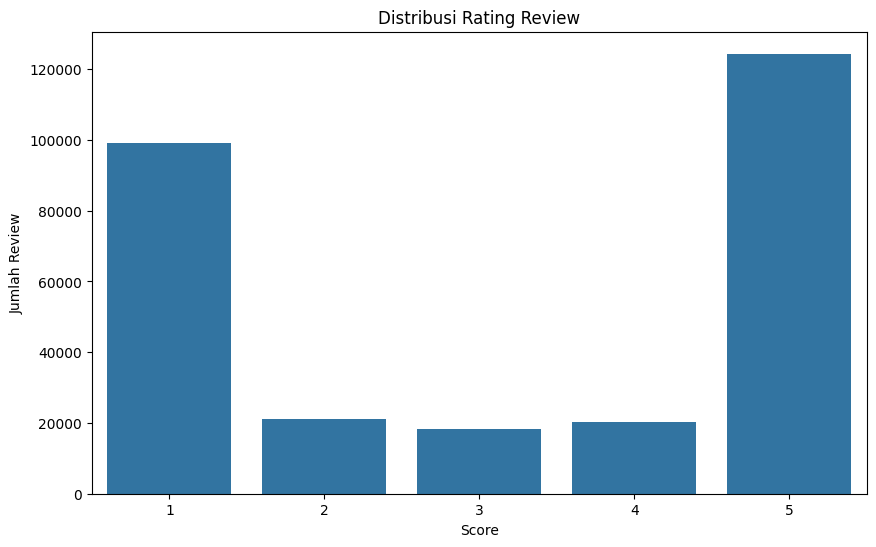

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(x='score', data=df)
plt.title("Distribusi Rating Review")
plt.xlabel("Score")
plt.ylabel("Jumlah Review")
plt.show()

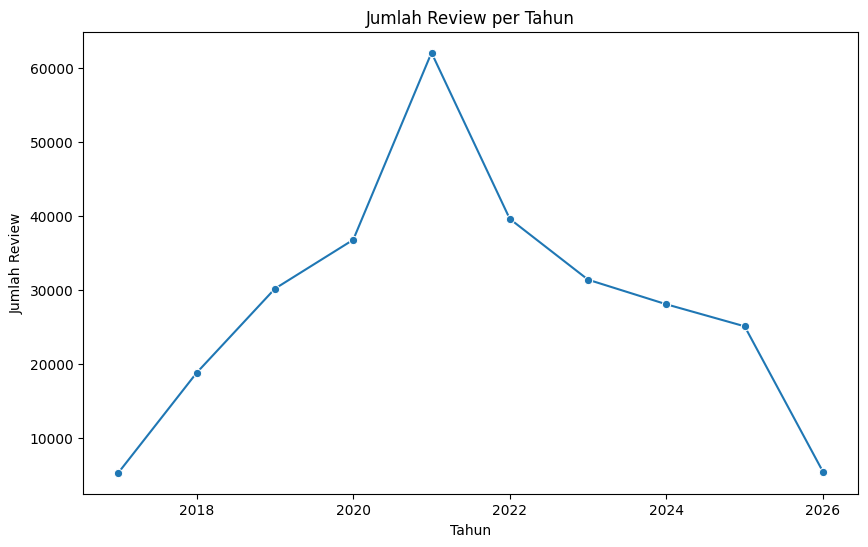

In [4]:
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year

year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title("Jumlah Review per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Review")
plt.show()

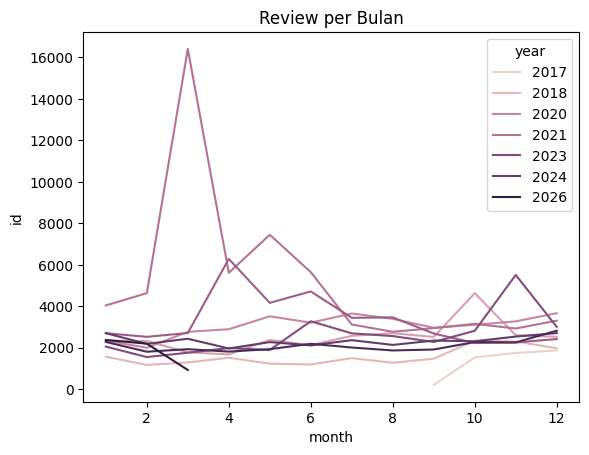

In [5]:
df['month'] = df['at'].dt.month

reviews_per_month = df.groupby(['year','month'])['id'].count().reset_index()

sns.lineplot(data=reviews_per_month, x='month', y='id', hue='year')
plt.title("Review per Bulan")
plt.show()

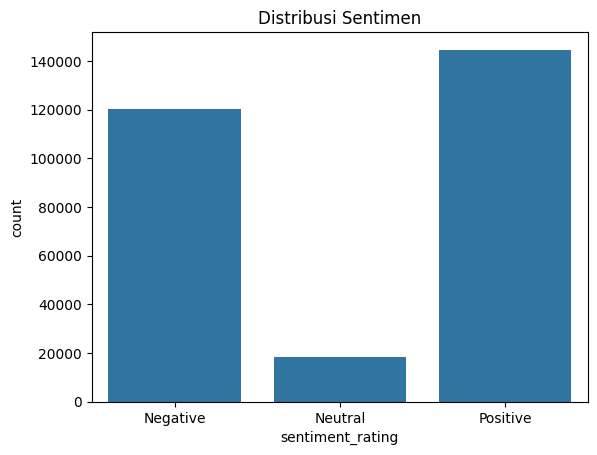

In [6]:
sns.countplot(x='sentiment_rating', data=df)
plt.title("Distribusi Sentimen")
plt.show()

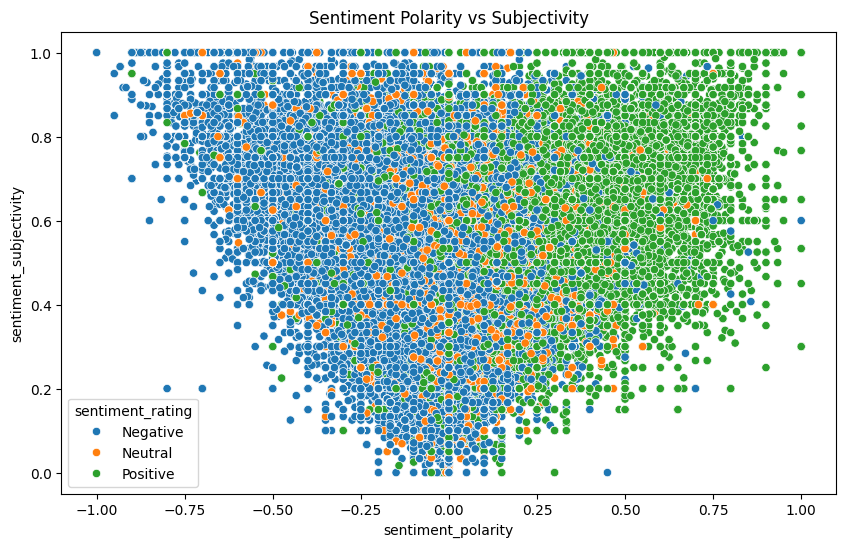

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['sentiment_polarity'],
    y=df['sentiment_subjectivity'],
    hue=df['sentiment_rating']
)
plt.title("Sentiment Polarity vs Subjectivity")
plt.show()

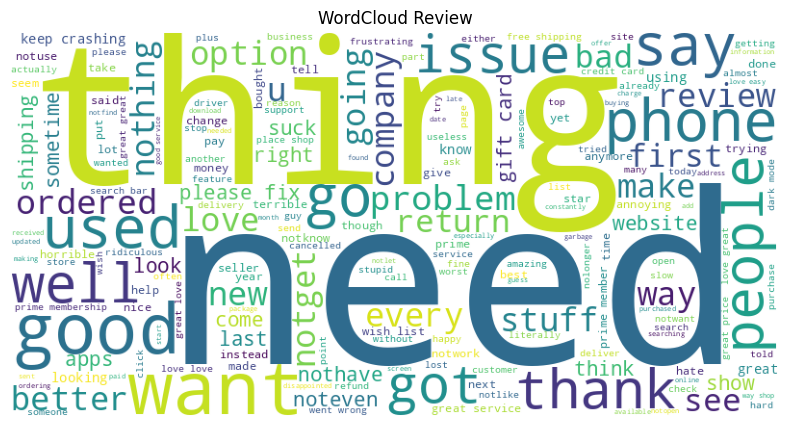

In [8]:
text = " ".join(df['cleaned_text'].dropna())

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud Review")
plt.show()

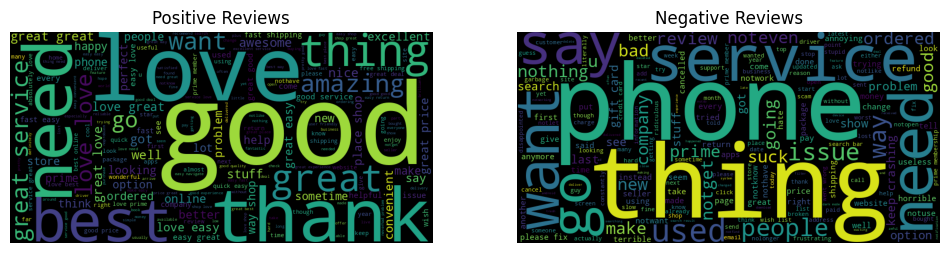

In [20]:
positive = df[df['sentiment_rating']=='Positive']['cleaned_text']
negative = df[df['sentiment_rating']=='Negative']['cleaned_text']

wc_pos = WordCloud(width=800, height=400).generate(" ".join(positive.dropna()))
wc_neg = WordCloud(width=800, height=400).generate(" ".join(negative.dropna()))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Reviews")

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Reviews")

plt.show()

# BoW

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

df = pd.read_csv('df_amazon_reviews2.csv')

texts = df['cleaned_text'].dropna()

In [14]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

print("Shape matrix:", X.shape)

Shape matrix: (280728, 30136)


In [15]:
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20])

['aaaaaaaaaaaa' 'aaaaarrrgggghhhh' 'aaaakkkktthhhhooooo' 'aah' 'aaliyah'
 'aaron' 'ab' 'aba' 'abandon' 'abandoned' 'abandoning' 'abased' 'abate'
 'abb' 'abba' 'abbas' 'abbey' 'abbot' 'abby' 'abc']


In [16]:
import pandas as pd

bow_df = pd.DataFrame(X.toarray(), columns=feature_names)
print(bow_df.head())

   aaaaaaaaaaaa  aaaaarrrgggghhhh  aaaakkkktthhhhooooo  aah  aaliyah  aaron  \
0             0                 0                    0    0        0      0   
1             0                 0                    0    0        0      0   
2             0                 0                    0    0        0      0   
3             0                 0                    0    0        0      0   
4             0                 0                    0    0        0      0   

   ab  aba  abandon  abandoned  ...  zombie  zone  zoning  zoo  zoom  zoomed  \
0   0    0        0          0  ...       0     0       0    0     0       0   
1   0    0        0          0  ...       0     0       0    0     0       0   
2   0    0        0          0  ...       0     0       0    0     0       0   
3   0    0        0          0  ...       0     0       0    0     0       0   
4   0    0        0          0  ...       0     0       0    0     0       0   

   zooming  zug  zzrsszeuseaa  zzz  
0      

In [17]:
word_counts = bow_df.sum().sort_values(ascending=False)

print("Top 20 words:")
print(word_counts.head(20))

Top 20 words:
great       33538
love        31999
good        25069
service     24494
prime       20645
easy        19424
need        16934
thing       14716
keep        13325
phone       12612
money       11893
price       11848
want        11703
shipping    11460
make        11454
best        11411
go          11237
search      10640
shop        10595
new         10371
dtype: int64


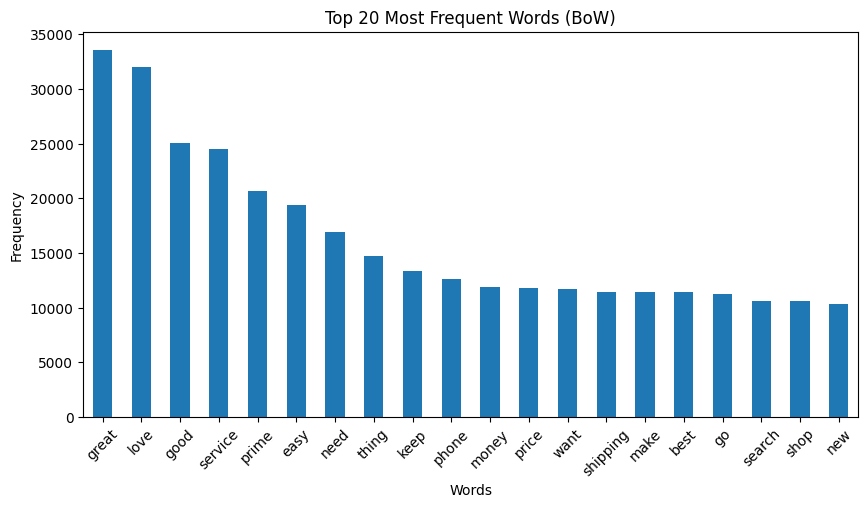

In [18]:
import matplotlib.pyplot as plt

top_words = word_counts.head(20)

plt.figure(figsize=(10,5))
top_words.plot(kind='bar')
plt.title("Top 20 Most Frequent Words (BoW)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()